<a href="https://colab.research.google.com/github/amirf95/Image-processing/blob/hmw1/AII419_Lab02_ImageEnhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AII419 – Image Processing
## Lab 2: Image Enhancement in Spatial and Frequency Domains

**Objectives**
- Spatial enhancement: negative, log, gamma, histogram equalization
- Frequency enhancement: FFT, magnitude spectrum, LPF/HPF
- Compare spatial vs frequency results and discuss artifacts


### Setup
Install (if needed):
```bash
pip install opencv-python numpy matplotlib
```

In [14]:
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
ASSETS = Path('assets')
print('Assets:', list(ASSETS.iterdir()) if ASSETS.exists() else 'No assets folder found')

Assets: [PosixPath('assets/sample_gray.png'), PosixPath('assets/checkerboard.png'), PosixPath('assets/stripes.png')]


### Part A — Spatial Domain Enhancement
**1) Load and display the image**

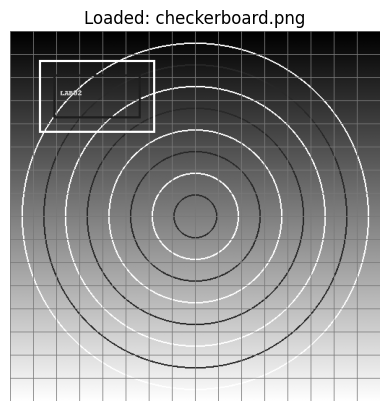

In [15]:
img_path = (ASSETS/'checkerboard.png') if (ASSETS/'checkerboard.png').exists() else (ASSETS/'stripes.png')
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
assert img is not None, 'Image not loaded'
plt.imshow(img, cmap='gray'); plt.title(f'Loaded: {img_path.name}'); plt.axis('off'); plt.show()

**2) Negative Transformation**

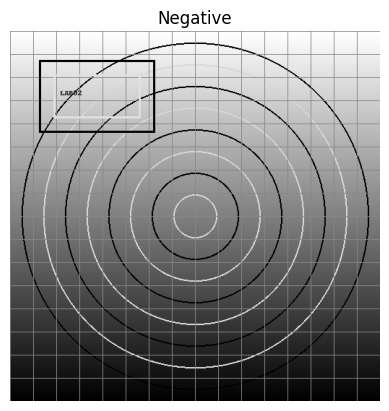

In [16]:
neg = 255 - img
plt.imshow(neg, cmap='gray'); plt.title('Negative'); plt.axis('off'); plt.show()

**3) Log Transformation**

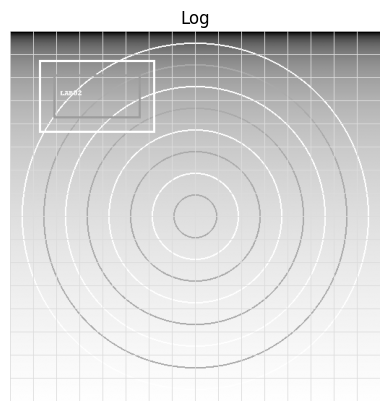

In [17]:
imgf = img.astype(np.float32)
c = 255.0/np.log(1+imgf.max())
log_img = (c*np.log(1+imgf)).clip(0,255).astype(np.uint8)
plt.imshow(log_img, cmap='gray'); plt.title('Log'); plt.axis('off'); plt.show()

**4) Gamma Transformation**

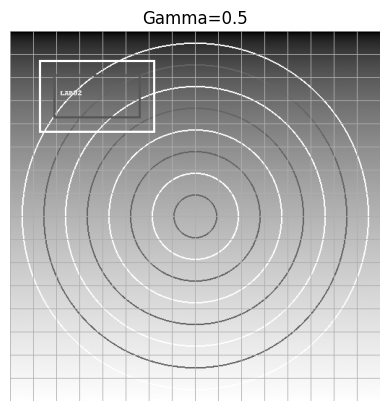

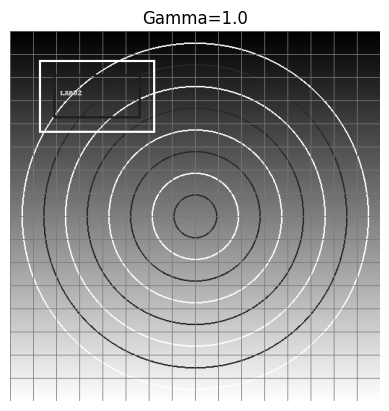

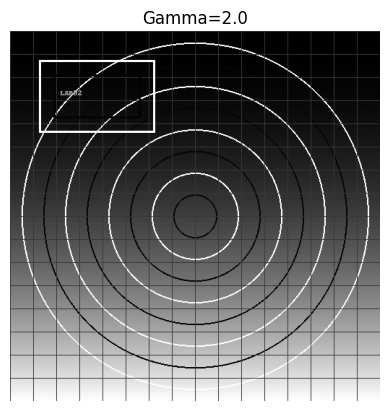

In [18]:
def gamma_correct(im, g=0.5):
    imf = im.astype(np.float32)/255.0
    out = np.power(imf, g)
    return (out*255).clip(0,255).astype(np.uint8)
for g in [0.5, 1.0, 2.0]:
    plt.imshow(gamma_correct(img,g), cmap='gray'); plt.title(f'Gamma={g}'); plt.axis('off'); plt.show()

**5) Histogram Equalization**

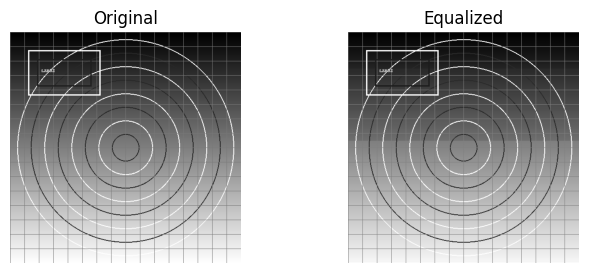

In [19]:
eq = cv2.equalizeHist(img)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(eq, cmap='gray'); plt.title('Equalized'); plt.axis('off')
plt.show()

### Part B — Frequency Domain Enhancement
**1) FFT and magnitude spectrum**

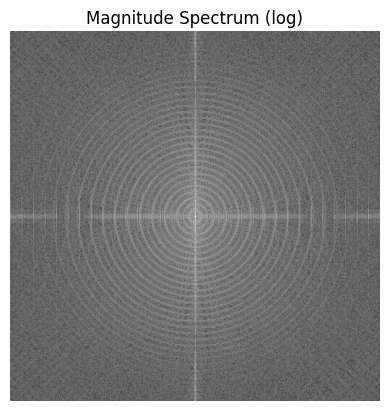

In [20]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
mag = 20*np.log(np.abs(fshift)+1e-8)
plt.imshow(mag, cmap='gray'); plt.title('Magnitude Spectrum (log)'); plt.axis('off'); plt.show()

**2) Ideal Low-Pass Filter**

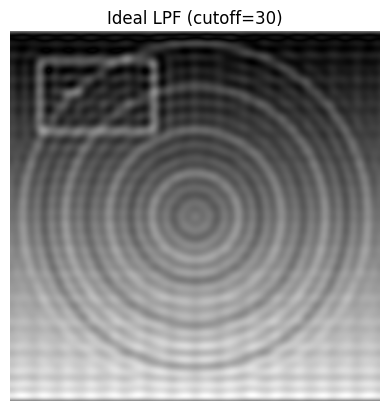

In [21]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2
mask = np.zeros((rows, cols), np.uint8)
cutoff = 30
import cv2
cv2.circle(mask, (ccol, crow), cutoff, 1, -1)
f_low = fshift * mask
img_low = np.abs(np.fft.ifft2(np.fft.ifftshift(f_low)))
plt.imshow(img_low, cmap='gray'); plt.title(f'Ideal LPF (cutoff={cutoff})'); plt.axis('off'); plt.show()

**3) Ideal High-Pass Filter**

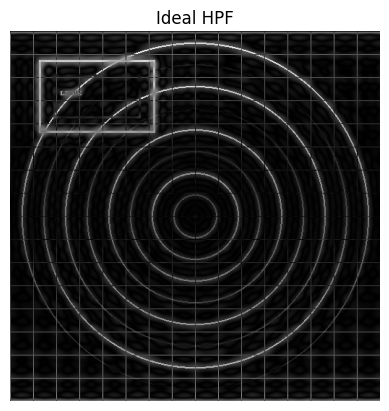

In [22]:
mask_hp = 1 - mask
f_high = fshift * mask_hp
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(f_high)))
plt.imshow(img_high, cmap='gray'); plt.title('Ideal HPF'); plt.axis('off'); plt.show()

**4) Gaussian LPF/HPF (optional)**

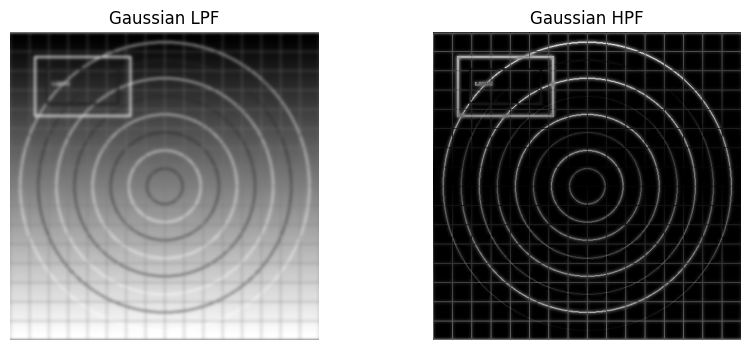

In [23]:
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
D2 = (X-ccol)**2 + (Y-crow)**2
D0 = 30.0
H_lpf = np.exp(-D2/(2*(D0**2)))
H_hpf = 1.0 - H_lpf
img_glow = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift*H_lpf)))
img_ghigh = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift*H_hpf)))
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img_glow, cmap='gray'); plt.title('Gaussian LPF'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_ghigh, cmap='gray'); plt.title('Gaussian HPF'); plt.axis('off')
plt.show()

### Part C — Comparison & Artifacts

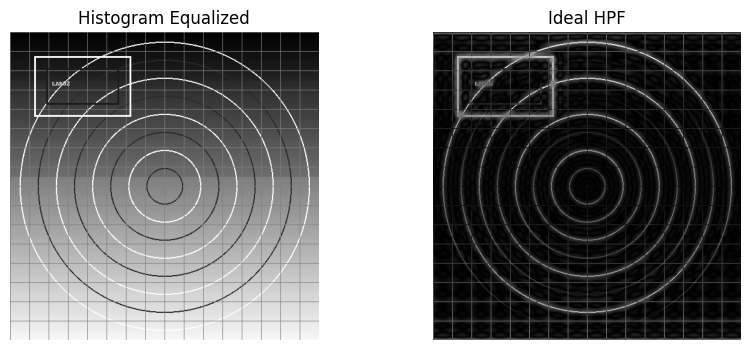

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(eq, cmap='gray'); plt.title('Histogram Equalized'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_high, cmap='gray'); plt.title('Ideal HPF'); plt.axis('off')
plt.show()

### Part D — Discussion (answer in Markdown)
1. Effect of gamma < 1 vs gamma > 1?
2. Why does histogram equalization enhance contrast?
3. Why do ideal filters cause ringing artifacts?
4. Spatial vs frequency filtering: computational and visual differences?


1. **Effect of gamma < 1 vs gamma > 1?**
    - **Gamma < 1**: Brightens the image by increasing the intensity of darker regions more significantly than brighter regions. This can help to reveal details in underexposed areas.
    - **Gamma > 1**: Darkens the image by decreasing the intensity of brighter regions more significantly than darker regions. This can help to suppress details in overexposed areas.

2. **Why does histogram equalization enhance contrast?**
    Histogram equalization works by redistributing the intensity values of an image such that the histogram of the output image is approximately flat or uniform. This process stretches the range of intensity values, especially those that are clustered in a narrow range, across the full dynamic range of the image. By doing so, it increases the global contrast of many images, especially when the usable data of the image is represented by a narrow range of contrast values.

3. **Why do ideal filters cause ringing artifacts?**
    Ideal filters (like the ideal low-pass or high-pass filters) have a sharp, abrupt cutoff in the frequency domain. This sharp transition corresponds to a sinc function in the spatial domain. When convolved with an image, the oscillations of the sinc function manifest as ringing artifacts around sharp edges or strong intensity changes in the filtered image. This phenomenon is known as the Gibbs phenomenon.

4. **Spatial vs frequency filtering: computational and visual differences?**
    -   **Computational Differences:**
        -   **Spatial Filtering:** Operations are performed directly on the image pixels. They typically involve convolution with a small kernel (e.g., a 3x3 or 5x5 matrix). The computational complexity depends on the size of the kernel and the image. For large kernels, it can be computationally expensive.
        -   **Frequency Filtering:** Operations are performed in the frequency domain after transforming the image using the Fourier Transform (FFT). Filtering involves multiplying the image's Fourier Transform by a filter function and then performing an Inverse Fourier Transform (IFFT) to get back to the spatial domain. For large images, FFT/IFFT operations are highly efficient (O(N log N)), making frequency filtering faster than spatial filtering for large kernels.

    -   **Visual Differences:**
        -   **Spatial Filtering:** Often results in localized effects. For example, a smoothing filter will blur nearby pixels. Edge detection filters highlight local intensity changes. Artifacts (if any) tend to be localized blurs or sharpenings.
        -   **Frequency Filtering:** Can produce more global effects. Filters like low-pass and high-pass in the frequency domain can affect all parts of the image simultaneously, leading to blurring or sharpening across the entire image. A notable visual artifact, especially with ideal frequency filters, is **ringing** (Gibbs phenomenon) around sharp edges due to the abrupt cutoff in the frequency domain, which is less common in spatial filtering.